# QC summary + technical replicate concordance

## Purpose
This notebook generates basic QC summaries and figures for the Xenium single-cell AnnData object used throughout the analysis. It focuses on:
- Library depth QC across conditions
- Per-sample QC summary table (used for manuscript supplementary QC table)
- A numbered UMAP figure for cell type visualization
- Technical replicate concordance via pseudobulk gene expression correlation

## Inputs
**Primary input**
- `mel_cytokines_andata.h5ad` (AnnData), loaded via `scanpy.read_h5ad(...)`.

**AnnData requirements**
This notebook assumes the AnnData object contains:
- `adata.obs` columns:
  - `Condition` (condition label)
  - `total_counts` (UMIs per cell)
  - `sample_id`, `mouse_id` (for per-sample QC table)
  - `cell_type` (categorical cell-type annotation)
  - `harvest_day` (used in condition_day labeling for tech-rep QC)
  - `tech_rep` (technical replicate ID; may include NaNs)
  - Optional morphology fields: `cell_area`, `nucleus_area`, `nucleus_count`
- `adata.obsm["X_umap"]` (UMAP coordinates used for plotting)
- `adata.layers["counts"]` (raw counts used for pseudobulk)
- `adata.uns["immune_obs_names"]` (list of obs_names defining immune cells for tech-rep QC)


## Outputs (written to the current working directory unless changed)
- `library_depth_by_condition.png` and `library_depth_by_condition.pdf`
- `Supplementary_Table_QC_summary_publication.csv` (per-sample QC summary table)
- `umap_celltype_numbered.png` and `umap_celltype_numbered.pdf`
- `qc_techrep_correlation_condition_day.pdf` (pseudobulk tech-rep concordance plot)


## Run order
Run cells top-to-bottom:
1) Load AnnData and set paths
2) Plot library depth by condition
3) Create/export per-sample QC summary table
4) Generate numbered UMAP plot
5) Compute and plot technical replicate concordance

In [1]:
# mamba activate squidpy-voyagerpy_v1 
import scanpy as sc
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import alphashape as alphashape
import geopandas as gpd


/vf/users/kanferg/conda_v1/envs/squidpy-voyagerpy_v1/lib/python3.8/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load input AnnData
Set `pathout` to the directory that contains `mel_cytokines_andata.h5ad`.
This file should already include QC fields in `.obs`, UMAP coordinates in `.obsm["X_umap"]`,
and raw counts in `.layers["counts"]`.

In [ ]:
# Large input files for this notebook are hosted on Zenodo; download and unpack the Zenodo bundle locally and set the base data path below to your local folder.
DATA_ROOT = "data_external/nguyenlab-il15act-dataset-v1"
pathout = os.path.join(DATA_ROOT, "01_processed_anndata")
metadata_notes_dir = os.path.join(DATA_ROOT, "00_metadata")
adata_concat = sc.read_h5ad(os.path.join(pathout, "mel_cytokines_andata.h5ad"))

## Library depth QC by condition
Creates a boxplot of per-cell total UMIs (`obs["total_counts"]`) grouped by `obs["Condition"]`.
Outputs: `library_depth_by_condition.png/.pdf`.

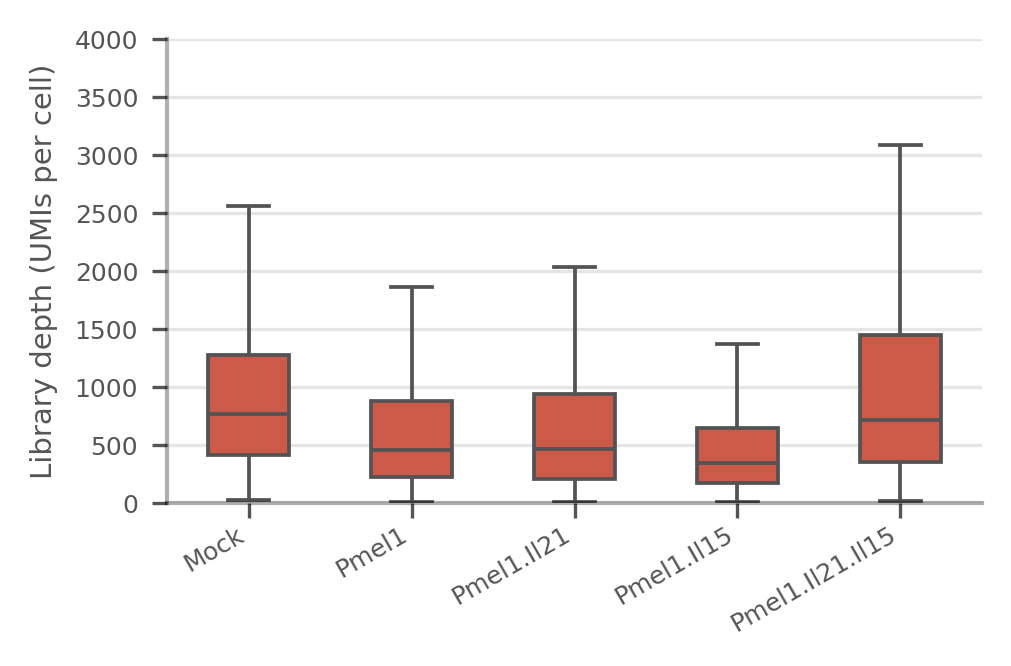

In [3]:
from matplotlib.ticker import MultipleLocator

depth_col = "total_counts"
cond_col  = "Condition"

# --- smaller inline in VSCode ---
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

df = adata_concat.obs[[cond_col, depth_col]].copy()
df = df.dropna(subset=[cond_col, depth_col])
df[depth_col] = pd.to_numeric(df[depth_col], errors="coerce")
df = df.dropna(subset=[depth_col])

fig, ax = plt.subplots(figsize=(3.25, 2.1))

# Simple box plot, hide fliers (outliers) for a cleaner journal look
sns.boxplot(
    data=df, x=cond_col, y=depth_col,
    width=0.5,
    showfliers=False,
    linewidth=0.9,
    ax=ax
)

# Optional: add a very light jittered sample of points (comment out if you want cleaner)
# sns.stripplot(
#     data=df.sample(min(len(df), 4000), random_state=0),
#     x=cond_col, y=depth_col,
#     size=1, jitter=0.25, alpha=0.25,
#     ax=ax
# )

ax.set_xlabel("")
ax.set_ylabel("Library depth (UMIs per cell)")

ax.tick_params(axis="x", labelrotation=30, pad=1)
plt.setp(ax.get_xticklabels(), ha="right")

# Y ticks every 500 (optional; comment out if cluttered)
ax.yaxis.set_major_locator(MultipleLocator(500))

# Optional: set y-limit to a percentile to avoid one extreme value dominating the scale
# (still keeps all data in the stats; it only changes the view)
ymax = np.quantile(df[depth_col], 0.995)
ymax_round = int(np.ceil(ymax / 500) * 500)
ax.set_ylim(0, 4000)


fig.savefig("library_depth_by_condition.png", bbox_inches="tight")
fig.savefig("library_depth_by_condition.pdf", bbox_inches="tight")

sns.despine(ax=ax)
fig.tight_layout(pad=0.4)



plt.show()


## Per-sample QC summary table (Supplementary QC table)
Aggregates per-cell QC metrics into a per-sample table grouped by:
- `sample_id`, `Condition`, `mouse_id`

The exported CSV is intended to match the manuscript supplementary QC summary.
Outputs: `Supplementary_Table_QC_summary_publication.csv`.

In [4]:
df = adata_concat.obs.copy()

# ---- required columns ----
group_cols = ["sample_id", "Condition", "mouse_id"]
depth_col  = "total_counts"

# ensure numeric
numeric_cols = [depth_col, "cell_area", "nucleus_area", "nucleus_count"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=group_cols + [depth_col]).copy()

def q(x, p):
    x = x.dropna().to_numpy()
    return float(np.quantile(x, p)) if len(x) else np.nan

def safe_median(x):
    x = x.dropna().to_numpy()
    return float(np.median(x)) if len(x) else np.nan

def safe_count(x):
    return int(pd.Series(x).notna().sum())

# =========================
# 1) Library depth summary per sample
# =========================
depth_summary = (
    df.groupby(group_cols, observed=True)[depth_col]
      .agg(
          n_cells=safe_count,
          mean_depth="mean",
          median_depth=safe_median,
          q05_depth=lambda x: q(x, 0.05),
          q25_depth=lambda x: q(x, 0.25),
          q75_depth=lambda x: q(x, 0.75),
          q95_depth=lambda x: q(x, 0.95),
          p99_depth=lambda x: q(x, 0.99),
          max_depth="max",
      )
      .reset_index()
)

# =========================
# 2) Morphology summary per sample
# =========================
morph_tables = []

if "cell_area" in df.columns:
    morph_tables.append(
        df.groupby(group_cols, observed=True)["cell_area"]
          .agg(
              median_cell_area=safe_median,
              q25_cell_area=lambda x: q(x, 0.25),
              q75_cell_area=lambda x: q(x, 0.75),
              p95_cell_area=lambda x: q(x, 0.95),
          )
          .reset_index()
    )

if "nucleus_area" in df.columns:
    morph_tables.append(
        df.groupby(group_cols, observed=True)["nucleus_area"]
          .agg(
              median_nucleus_area=safe_median,
              q25_nucleus_area=lambda x: q(x, 0.25),
              q75_nucleus_area=lambda x: q(x, 0.75),
              p95_nucleus_area=lambda x: q(x, 0.95),
          )
          .reset_index()
    )

# nucleus_count: ONLY median
if "nucleus_count" in df.columns:
    morph_tables.append(
        df.groupby(group_cols, observed=True)["nucleus_count"]
          .agg(median_nucleus_count=safe_median)
          .reset_index()
    )

# Merge morphology tables
if morph_tables:
    morph_summary = morph_tables[0]
    for t in morph_tables[1:]:
        morph_summary = morph_summary.merge(t, on=group_cols, how="outer")
else:
    morph_summary = pd.DataFrame(columns=group_cols)

# =========================
# 3) Final QC table
# =========================
qc_table = depth_summary.merge(morph_summary, on=group_cols, how="left")
qc_table["iqr_depth"] = qc_table["q75_depth"] - qc_table["q25_depth"]

# Round numeric columns for publication
num_cols = [c for c in qc_table.columns if c not in group_cols]
qc_table[num_cols] = qc_table[num_cols].round(2)

qc_table = qc_table.sort_values(["Condition", "sample_id"])

qc_table.to_csv("Supplementary_Table_QC_summary_publication.csv", index=False)



In [5]:
qc_table.head()

,sample_id,Condition,mouse_id,n_cells,mean_depth,median_depth,q05_depth,q25_depth,q75_depth,q95_depth,...,median_cell_area,q25_cell_area,q75_cell_area,p95_cell_area,median_nucleus_area,q25_nucleus_area,q75_nucleus_area,p95_nucleus_area,median_nucleus_count,iqr_depth
22,4_M-1,Mock,762,19218,1172.310059,913.5,171.0,480.00,1539.00,3100.45,...,121.38,75.32,181.12,328.94,44.80,26.33,64.35,102.78,1.0,1059.00
9,4_M-2,Mock,789,8042,1176.150024,818.5,139.0,411.25,1548.75,3343.85,...,106.64,59.08,175.50,329.82,32.96,17.93,55.09,98.01,1.0,1137.50
31,4_M-3,Mock,790,7583,959.340027,672.0,57.0,300.00,1297.00,2820.70,...,85.30,48.50,141.07,273.78,25.56,14.31,45.02,83.76,1.0,997.00
13,8_M-1,Mock,771,30690,766.969971,664.0,96.0,360.00,1040.00,1798.00,...,87.22,58.52,121.10,186.16,35.04,21.18,49.60,71.35,1.0,680.00
38,8_M-2,Mock,784,5100,1095.880005,829.0,147.0,414.00,1460.25,2962.00,...,91.28,52.62,148.26,298.68,29.35,17.34,49.67,87.32,1.0,1046.25


## UMAP of cell types with numbered labels
Plots UMAP colored by cell type and writes a numbered legend + numeric labels on the embedding.
This is useful for compact figure legends in the manuscript.

Outputs: `umap_celltype_numbered.png/.pdf`.

Note: `legend_order` is manually defined; edit to match your cell-type names and desired ordering.

/vf/users/kanferg/conda_v1/envs/squidpy-voyagerpy_v1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


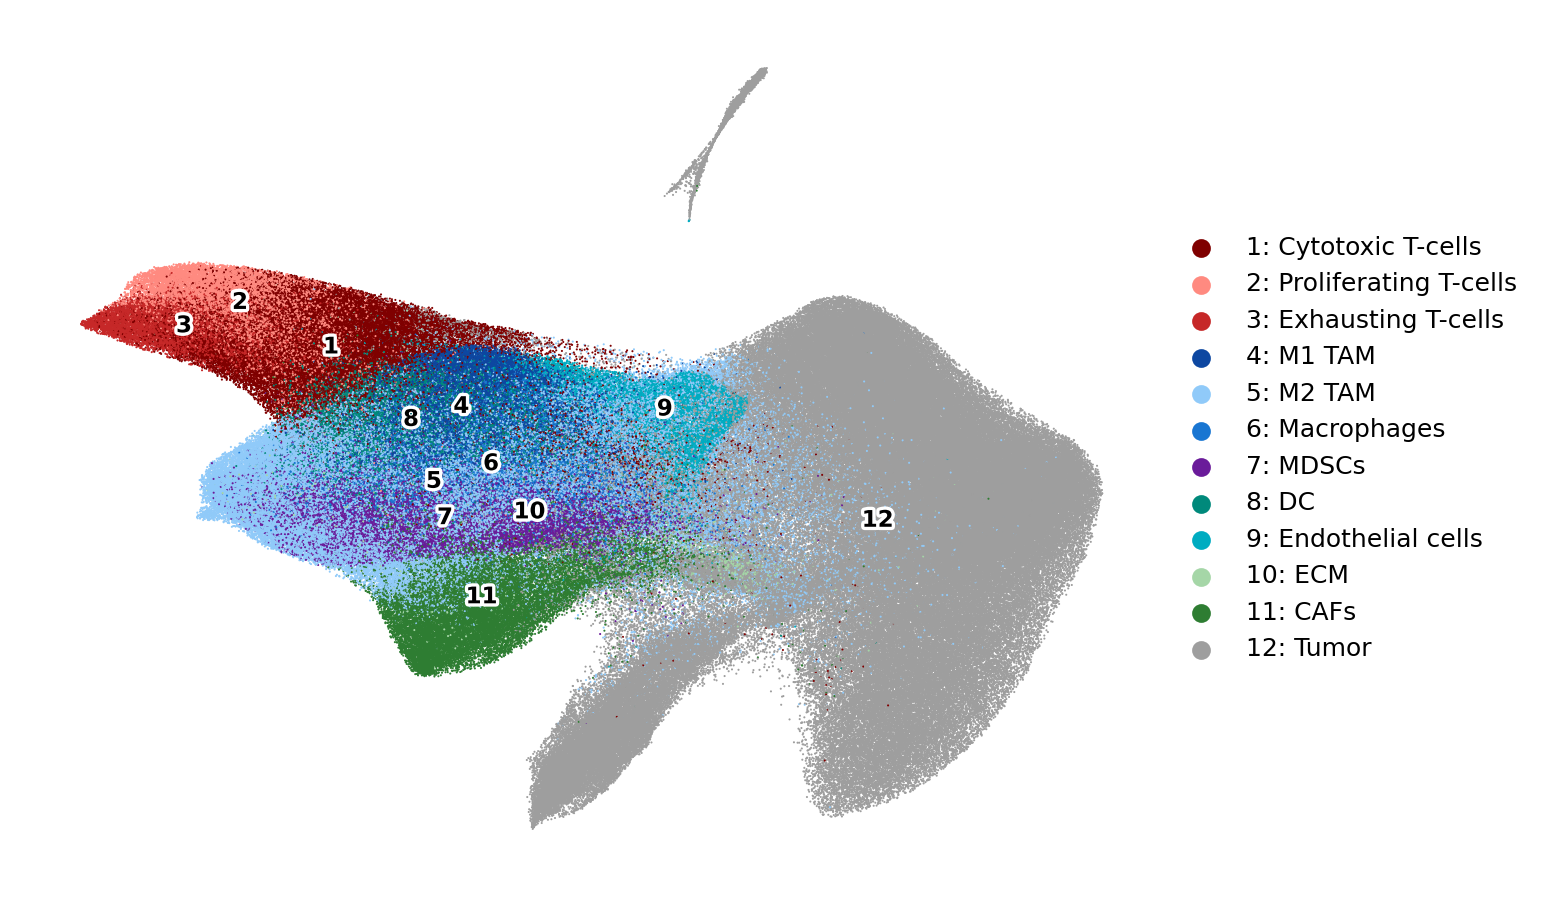

In [7]:
import matplotlib.patheffects as pe

adata = adata_concat  # <- your object
adata.obs['condition_in'] = adata.obs['Condition'].astype(str)=='Mock'
adata = adata[~adata.obs['condition_in']].copy()  # filter to only "Mock" condition for the UMAP plot

# 1) Desired legend order (edit names here if your categories differ)
legend_order = [
    "Cytotoxic T-cells",
    "Proliferating T-cells",
    "Exhausting T-cells",
    "M1 TAM",
    "M2 TAM",
    "Macrophages",
    "MDSCs",
    "DC",
    "Endothelial cells",
    "ECM",
    "CAFs",
    "Tumor",
]

# 2) Build a mapping from current cell_type -> current color (so we can reorder safely)
#    Scanpy stores colors aligned to adata.obs['cell_type'].cat.categories
if not pd.api.types.is_categorical_dtype(adata.obs["cell_type"]):
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

current_cats = list(adata.obs["cell_type"].cat.categories)
current_colors = list(adata.uns.get("cell_type_colors", []))
color_map = dict(zip(current_cats, current_colors)) if len(current_colors) == len(current_cats) else {}

# 3) Keep only types that actually exist in the data, in your requested order
present = [ct for ct in legend_order if ct in current_cats]
missing = [ct for ct in legend_order if ct not in current_cats]
if missing:
    print("These requested cell types were NOT found in adata.obs['cell_type'] and will be skipped:\n", missing)

# 4) Create a numbered label column for plotting/legend: "1: Cytotoxic T-cells", ...
num_map = {ct: f"{i+1}: {ct}" for i, ct in enumerate(present)}
adata.obs["cell_type_num"] = adata.obs["cell_type"].astype(str).map(num_map)
adata.obs["cell_type_num"] = adata.obs["cell_type_num"].astype("category")
adata.obs["cell_type_num"] = adata.obs["cell_type_num"].cat.set_categories(
    [num_map[ct] for ct in present], ordered=True
)

# 5) Rebuild colors in the new order (fall back to Scanpy default if mapping is missing)
new_colors = []
fallback = None
try:
    fallback = sc.pl.palettes.default_102  # decent default palette
except Exception:
    pass

for j, ct in enumerate(present):
    if ct in color_map:
        new_colors.append(color_map[ct])
    else:
        new_colors.append(fallback[j] if fallback is not None else "#808080")

adata.uns["cell_type_num_colors"] = new_colors

# 6) Plot the embedding
#    - basis is "X_umap" (stored in obsm)
#    - edgecolor black + thin line
#    - legend uses the numbered labels in the desired order

# plt.rcParams["figure.dpi"] = 300
# plt.rcParams["savefig.dpi"] = 300

# plt.rcParams.update({
#     "font.size": 7,
#     "axes.labelsize": 7,
#     "axes.titlesize": 8,
#     "xtick.labelsize": 6,
#     "ytick.labelsize": 6,
#     "legend.fontsize": 6,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
# })

fig, ax = plt.subplots(figsize=(5.2, 3.0), dpi=300)

ax_out = sc.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type_num",
    legend_loc="right margin",
    frameon=False,
    size=1,
    edgecolors="black",
    linewidths=0.15,
    show=False,
    ax=ax,
)

for coll in ax_out.collections:
    coll.set_rasterized(True)
    
ax_out.set_title("", fontsize=8)
    
# 7) Put the numbers ON the UMAP (one label per cell type at median position)
X = adata.obsm["X_umap"]
df = pd.DataFrame(X, columns=["x", "y"], index=adata.obs_names)
df["lab"] = adata.obs["cell_type_num"].astype(str).values

centers = df.groupby("lab")[["x", "y"]].median()

label_fs = 5.5          # try 4.5–6.0 for your current figure size
outline_lw = 1.6        # try 1.2–2.0

for lab, (x, y) in centers.iterrows():
    num = lab.split(":")[0].strip()
    t = ax.text(x, y, num, ha="center", va="center",
                fontsize=label_fs, weight="bold")
    t.set_path_effects([pe.withStroke(linewidth=outline_lw, foreground="white")])


fig.savefig("umap_celltype_numbered.pdf", bbox_inches="tight")
fig.savefig("umap_celltype_numbered.png", bbox_inches="tight")

plt.tight_layout()
plt.show()

## Technical replicate concordance (pseudobulk correlation)
Assesses agreement between technical replicates by:
1) Selecting immune cells (`adata.uns["immune_obs_names"]`)
2) Summing raw counts across cells within each (condition_day × tech_rep) group (pseudobulk)
3) CPM-normalizing and log1p transforming per group
4) Scatter-plotting gene-wise values between replicate pairs and reporting Pearson correlation

Output: `qc_techrep_correlation_condition_day.pdf`.

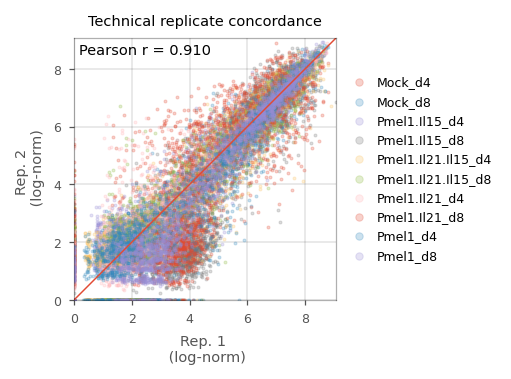

In [8]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def pseudobulk_sum_counts(adata, group_cols, counts_layer="counts"):
    X = adata.layers[counts_layer]
    if sp.issparse(X):
        X = X.tocsr()

    groups = adata.obs[group_cols].astype(str).agg("|".join, axis=1)
    cat = pd.Categorical(groups)
    codes = cat.codes
    n_groups = len(cat.categories)

    G = sp.csr_matrix(
        (np.ones(adata.n_obs, dtype=np.float32), (codes, np.arange(adata.n_obs))),
        shape=(n_groups, adata.n_obs),
    )

    PB = G @ X  # summed counts (groups x genes)
    if sp.issparse(PB):
        PB = PB.toarray()

    pb_counts = pd.DataFrame(PB, index=cat.categories, columns=adata.var_names)
    meta = pd.DataFrame([s.split("|") for s in pb_counts.index], columns=group_cols, index=pb_counts.index)
    return pb_counts, meta

def normalize_log1p(pb_counts, target_sum=1e6):
    # CPM-like normalization then log1p (natural log)
    lib = pb_counts.sum(axis=1).replace(0, np.nan)
    pb_norm = pb_counts.div(lib, axis=0) * target_sum
    pb_log = np.log1p(pb_norm)
    return pb_log

# ---- build immune adata + condition_day ----
adata = adata_concat[adata_concat.uns["immune_obs_names"]].copy()
adata.obs["condition_day"] = (
    adata.obs["Condition"].astype(str) + "_d" + adata.obs["harvest_day"].astype(str)
)
adata_tr = adata[~adata.obs["tech_rep"].isna()].copy()

# ---- pseudobulk counts by (condition_day, tech_rep) ----
pb_counts, meta = pseudobulk_sum_counts(adata_tr, ["condition_day", "tech_rep"], counts_layer="counts")
pb = normalize_log1p(pb_counts, target_sum=1e6)  # log1p(CPM); use 1e4 if you prefer CP10K

# valid condition_days with >=2 reps
valid_days = (
    meta.groupby("condition_day")["tech_rep"]
        .nunique()
        .pipe(lambda s: s[s >= 2])
        .index
        .tolist()
)

# ---- one combined plot + global Pearson (Option 1 concat) ----
plt.rcParams.update({
    "font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "figure.dpi": 150, "savefig.dpi": 600, "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.25, 3.25))

handles, labels = [], []
global_min = np.inf
global_max = -np.inf
X_all, Y_all = [], []

for cd in sorted(valid_days):
    sub = meta[meta["condition_day"] == cd]
    reps = sorted(sub["tech_rep"].unique())[:2]

    a_idx = sub[sub["tech_rep"] == reps[0]].index[0]
    b_idx = sub[sub["tech_rep"] == reps[1]].index[0]

    x = pb.loc[a_idx].values
    y = pb.loc[b_idx].values

    X_all.append(x); Y_all.append(y)

    r_cd = np.corrcoef(x, y)[0, 1]
    global_min = min(global_min, float(np.nanmin([x.min(), y.min()])))
    global_max = max(global_max, float(np.nanmax([x.max(), y.max()])))

    sc = ax.scatter(x, y, s=2.0, alpha=0.25, rasterized=True)
    handles.append(sc)
    labels.append(f"{cd}")

X_all = np.concatenate(X_all)
Y_all = np.concatenate(Y_all)
r_global, p_global = pearsonr(X_all, Y_all)

ax.plot([global_min, global_max], [global_min, global_max], linewidth=0.7)
ax.set_xlim(global_min, global_max)
ax.set_ylim(global_min, global_max)
ax.set_aspect("equal", adjustable="box")
ax.tick_params(direction="out")

ax.set_xlabel("Rep. 1 \n (log-norm)")
ax.set_ylabel("Rep. 2 \n (log-norm)")
ax.set_title("Technical replicate concordance")

ax.text(
    0.02, 0.98,
    f"Pearson r = {r_global:.3f}",
    transform=ax.transAxes,
    ha="left", va="top"
)

ax.legend(
    handles, labels,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, handletextpad=0.4, borderaxespad=0.0, markerscale=2.5,
)

fig.savefig("qc_techrep_correlation_condition_day.pdf", bbox_inches="tight")

fig.tight_layout(pad=0.2)
plt.show()


